In [29]:
import torch
import librosa
import transformers
import numpy
import pandas

print("Environment ready ✅")

Environment ready ✅


In [31]:
import os
import pandas as pd
import librosa
import numpy as np


# -------------------------------------------------
# Create RAVDESS dataset (paths + emotion labels)
# -------------------------------------------------
def create_ravdess_dataset(directory_path):

    emotion_map = {
        '01': 'neutral',
        '02': 'calm',
        '03': 'happy',
        '04': 'sad',
        '05': 'angry',
        '06': 'fearful',
        '07': 'disgust',
        '08': 'surprised'
    }

    dataset = []

    for subdir, _, files in os.walk(directory_path):
        for file in files:

            if not file.lower().endswith(".wav"):
                continue

            parts = file.split("-")

            if len(parts) < 7:
                continue

            vocal_channel = parts[1]
            emotion_code = parts[2]

            if vocal_channel != "01":
                continue

            if emotion_code in emotion_map:

                dataset.append({
                    "path": os.path.join(subdir, file),
                    "emotion": emotion_map[emotion_code]
                })

    return dataset


# -------------------------------------------------
# FORMANT EXTRACTION (stable LPC frame-based)
# -------------------------------------------------
def extract_formants(y, sr, n_formants=3):
    try:
        # 1. Pre-emphasis
        y = librosa.effects.preemphasis(y)

        # 2. Frame parameters
        frame_length = int(0.025 * sr)
        hop_length = int(0.010 * sr)

        frames = librosa.util.frame(
            y,
            frame_length=frame_length,
            hop_length=hop_length
        )

        # Generate a window function to prevent edge discontinuities
        window = np.hamming(frame_length)
        
        formant_values = []

        for frame in frames.T:
            # 3. Energy check (skip silence and highly unvoiced frames)
            if np.max(np.abs(frame)) < 0.02:
                continue

            # Apply the window to the frame BEFORE calculating LPC
            windowed_frame = frame * window

            order = 2 + sr // 1000
            lpc_coeffs = librosa.lpc(windowed_frame, order=order)

            # 4. Find roots and keep only positive imaginary parts
            roots = np.roots(lpc_coeffs)
            roots = roots[np.imag(roots) > 0] 

            # Calculate frequencies
            angles = np.arctan2(np.imag(roots), np.real(roots))
            freqs = angles * (sr / (2 * np.pi))

            # 5. Calculate Bandwidths
            # Formula: B = -(sr / pi) * ln(|r|)
            bws = -(sr / np.pi) * np.log(np.abs(roots))

            # 6. Filter by frequency range AND bandwidth
            valid_formants = []
            for f, bw in zip(freqs, bws):
                # A bandwidth > 400Hz usually means it's spectral tilt, not a formant
                if 90 < f < 5000 and bw < 400:
                    valid_formants.append(f)

            valid_formants = sorted(valid_formants)

            if len(valid_formants) >= n_formants:
                formant_values.append(valid_formants[:n_formants])

        if len(formant_values) == 0:
            return [0.0] * n_formants

        # Return the mean of the tracked formants over valid frames
        return np.mean(formant_values, axis=0).tolist()

    except Exception as e:
        # Actually print the error so you know if something breaks
        print(f"Formant extraction failed: {e}")
        return [0.0] * n_formants


# -------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------
def extract_features(df, n_mfcc=13, lpc_order=12):

    features = []

    for idx, row in df.iterrows():

        try:

            path = row["path"]

            if not os.path.exists(path):
                continue

            y, sr = librosa.load(path, sr=16000)

            if len(y) == 0:
                continue


            # =====================
            # MFCC
            # =====================
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std = np.std(mfcc, axis=1)


            # =====================
            # CHROMAGRAM
            # =====================
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)

            chroma_mean = np.mean(chroma, axis=1)
            chroma_std = np.std(chroma, axis=1)


            # =====================
            # LPC
            # =====================
            lpc_coeffs = librosa.lpc(y, order=lpc_order)


            # =====================
            # FORMANTS
            # =====================
            formants = extract_formants(y, sr)


            features.append({

                "path": path,   # IMPORTANT FIX
                "emotion": row["emotion"],

                "mfcc_mean": mfcc_mean,
                "mfcc_std": mfcc_std,

                "chroma_mean": chroma_mean,
                "chroma_std": chroma_std,

                "lpc": lpc_coeffs,
                "formants": formants
            })

            print(f"Processed {idx+1}: {os.path.basename(path)}")

        except Exception as e:

            print(f"Error processing {path}: {e}")

    return features


# -------------------------------------------------
# MAIN SCRIPT
# -------------------------------------------------
ravdess_path = "speech"

ravdess_data = create_ravdess_dataset(ravdess_path)

df_ravdess = pd.DataFrame(ravdess_data)

print("Total samples:", len(df_ravdess))


# Extract features
extracted_features = extract_features(df_ravdess)


# -------------------------------------------------
# FLATTEN FEATURES
# -------------------------------------------------
flattened_features = []

for item in extracted_features:

    row = {
        "path": item["path"],
        "emotion": item["emotion"]
    }

    # MFCC
    for i, v in enumerate(item["mfcc_mean"]):
        row[f"mfcc_mean_{i}"] = v

    for i, v in enumerate(item["mfcc_std"]):
        row[f"mfcc_std_{i}"] = v


    # CHROMA
    for i, v in enumerate(item["chroma_mean"]):
        row[f"chroma_mean_{i}"] = v

    for i, v in enumerate(item["chroma_std"]):
        row[f"chroma_std_{i}"] = v


    # LPC
    for i, v in enumerate(item["lpc"]):
        row[f"lpc_{i}"] = v


    # FORMANTS
    for i, v in enumerate(item["formants"]):
        row[f"formant_{i+1}"] = v


    flattened_features.append(row)


df_features = pd.DataFrame(flattened_features)

csv_filename = "ser_features_mfcc_chroma_lpc_formants.csv"

df_features.to_csv(csv_filename, index=False)


print("\nFeature extraction complete")
print("Saved to:", csv_filename)
print("Shape:", df_features.shape)

Total samples: 1440
Processed 1: 03-01-01-01-01-01-01.wav
Processed 2: 03-01-01-01-01-02-01.wav
Processed 3: 03-01-01-01-02-01-01.wav
Processed 4: 03-01-01-01-02-02-01.wav
Processed 5: 03-01-02-01-01-01-01.wav
Processed 6: 03-01-02-01-01-02-01.wav
Processed 7: 03-01-02-01-02-01-01.wav
Processed 8: 03-01-02-01-02-02-01.wav
Processed 9: 03-01-02-02-01-01-01.wav
Processed 10: 03-01-02-02-01-02-01.wav
Processed 11: 03-01-02-02-02-01-01.wav
Processed 12: 03-01-02-02-02-02-01.wav
Processed 13: 03-01-03-01-01-01-01.wav
Processed 14: 03-01-03-01-01-02-01.wav
Processed 15: 03-01-03-01-02-01-01.wav
Processed 16: 03-01-03-01-02-02-01.wav
Processed 17: 03-01-03-02-01-01-01.wav
Processed 18: 03-01-03-02-01-02-01.wav
Processed 19: 03-01-03-02-02-01-01.wav
Processed 20: 03-01-03-02-02-02-01.wav
Processed 21: 03-01-04-01-01-01-01.wav
Processed 22: 03-01-04-01-01-02-01.wav
Processed 23: 03-01-04-01-02-01-01.wav
Processed 24: 03-01-04-01-02-02-01.wav
Processed 25: 03-01-04-02-01-01-01.wav
Processed 26: 

In [32]:
import torch
import pandas as pd
import numpy as np
import librosa
import os

from transformers import Wav2Vec2Model
from sklearn.preprocessing import StandardScaler, LabelEncoder


# ========================
# CONFIG
# ========================
CSV_PATH = "ser_features_mfcc_chroma_lpc_formants.csv"

OUTPUT_FEATURES = "ser_fused_features.npy"
OUTPUT_LABELS = "ser_labels.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_AUDIO_LEN = 16000 * 5  # 5 seconds


# ========================
# LOAD CSV
# ========================
df = pd.read_csv(CSV_PATH)

assert "path" in df.columns, "CSV must contain path column"

paths = df["path"].values
labels = df["emotion"]

print("Total samples:", len(paths))


# ========================
# NORMALIZE ACOUSTIC FEATURES
# ========================
X_acoustic = df.drop(columns=["emotion", "path"])

scaler = StandardScaler()

X_acoustic = scaler.fit_transform(X_acoustic)

print("Acoustic feature shape:", X_acoustic.shape)


# ========================
# LABEL ENCODING
# ========================
encoder = LabelEncoder()

y = encoder.fit_transform(labels)

print("Emotion classes:", encoder.classes_)


# ========================
# LOAD WAV2VEC2 MODEL
# ========================
print("\nLoading Wav2Vec2 model...")

wav2vec = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
).to(DEVICE)

wav2vec.eval()


# ========================
# AUDIO LOADER
# ========================
def load_audio(path):

    audio, sr = librosa.load(path, sr=16000)

    audio = torch.tensor(audio)

    if len(audio) > MAX_AUDIO_LEN:

        audio = audio[:MAX_AUDIO_LEN]

    else:

        pad = MAX_AUDIO_LEN - len(audio)

        audio = torch.nn.functional.pad(audio, (0, pad))

    return audio


# ========================
# EXTRACT WAV2VEC2 EMBEDDINGS
# ========================
wav_embeddings = []

print("\nExtracting Wav2Vec2 embeddings...\n")

with torch.no_grad():

    for i, path in enumerate(paths):

        try:

            audio = load_audio(path).to(DEVICE)

            audio = (audio - audio.mean()) / (audio.std() + 1e-7)

            output = wav2vec(audio.unsqueeze(0))

            embedding = output.last_hidden_state.mean(dim=1)

            wav_embeddings.append(
                embedding.squeeze().cpu().numpy()
            )

        except Exception as e:

            print("Skipping:", path)
            print(e)

            wav_embeddings.append(np.zeros(768))

        if (i + 1) % 50 == 0:

            print(f"{i+1}/{len(paths)} processed")


wav_embeddings = np.array(wav_embeddings)

print("\nWav2Vec2 embedding shape:", wav_embeddings.shape)


# ========================
# MERGE FEATURES
# ========================
X_fused = np.concatenate(
    [X_acoustic, wav_embeddings],
    axis=1
)

print("Final fused feature shape:", X_fused.shape)


# ========================
# SAVE DATASET
# ========================
np.save(OUTPUT_FEATURES, X_fused)

np.save(OUTPUT_LABELS, y)


print("\nSaved fused dataset successfully")

print("Feature file:", OUTPUT_FEATURES)
print("Label file:", OUTPUT_LABELS)

Total samples: 1440
Acoustic feature shape: (1440, 66)
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

Loading Wav2Vec2 model...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 3447.09it/s]
Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting Wav2Vec2 embeddings...

50/1440 processed
100/1440 processed
150/1440 processed
200/1440 processed
250/1440 processed
300/1440 processed
350/1440 processed
400/1440 processed
450/1440 processed
500/1440 processed
550/1440 processed
600/1440 processed
650/1440 processed
700/1440 processed
750/1440 processed
800/1440 processed
850/1440 processed
900/1440 processed
950/1440 processed
1000/1440 processed
1050/1440 processed
1100/1440 processed
1150/1440 processed
1200/1440 processed
1250/1440 processed
1300/1440 processed
1350/1440 processed
1400/1440 processed

Wav2Vec2 embedding shape: (1440, 768)
Final fused feature shape: (1440, 834)

Saved fused dataset successfully
Feature file: ser_fused_features.npy
Label file: ser_labels.npy


In [33]:
import numpy as np

from imblearn.over_sampling import SMOTE
from collections import Counter


# ========================
# CONFIG
# ========================
FEATURE_PATH = "ser_fused_features.npy"
LABEL_PATH   = "ser_labels.npy"

OUT_FEATURES = "ser_fused_features_smote_3072.npy"
OUT_LABELS   = "ser_labels_smote_3072.npy"

TARGET_PER_CLASS = 384   # 384 × 8 = 3072


# ========================
# LOAD DATA
# ========================
X = np.load(FEATURE_PATH)
y = np.load(LABEL_PATH)

print("Original feature shape:", X.shape)
print("Original label shape:", y.shape)


# ========================
# CLASS DISTRIBUTION
# ========================
counts = Counter(y)

print("\nOriginal class distribution:")
for k, v in counts.items():
    print(f"class {k}: {v}")


# ========================
# BUILD TARGET STRATEGY
# ========================
sampling_strategy = {
    cls: TARGET_PER_CLASS
    for cls in counts.keys()
}


print("\nTarget distribution per class:")
for k in sampling_strategy:
    print(f"class {k} → {sampling_strategy[k]}")


# ========================
# APPLY SMOTE
# ========================
smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=5
)

X_resampled, y_resampled = smote.fit_resample(X, y)


# ========================
# VERIFY OUTPUT
# ========================
print("\nAfter SMOTE distribution:")

new_counts = Counter(y_resampled)

for k, v in new_counts.items():
    print(f"class {k}: {v}")

print("\nTotal rows after SMOTE:", len(y_resampled))


# ========================
# SAVE DATASET
# ========================
np.save(OUT_FEATURES, X_resampled)
np.save(OUT_LABELS, y_resampled)


print("\nSaved balanced fused dataset successfully")
print("Feature file:", OUT_FEATURES)
print("Label file:", OUT_LABELS)
print("Final shape:", X_resampled.shape)

Original feature shape: (1440, 834)
Original label shape: (1440,)

Original class distribution:
class 5: 96
class 1: 192
class 4: 192
class 6: 192
class 0: 192
class 3: 192
class 2: 192
class 7: 192

Target distribution per class:
class 5 → 384
class 1 → 384
class 4 → 384
class 6 → 384
class 0 → 384
class 3 → 384
class 2 → 384
class 7 → 384

After SMOTE distribution:
class 5: 384
class 1: 384
class 4: 384
class 6: 384
class 0: 384
class 3: 384
class 2: 384
class 7: 384

Total rows after SMOTE: 3072

Saved balanced fused dataset successfully
Feature file: ser_fused_features_smote_3072.npy
Label file: ser_labels_smote_3072.npy
Final shape: (3072, 834)


Feature shape: (3072, 834)
Label shape: (3072,)

===== Fold 1 =====
Epoch 1 Val Acc: 0.3691
Epoch 2 Val Acc: 0.5187
Epoch 3 Val Acc: 0.6455
Epoch 4 Val Acc: 0.7431
Epoch 5 Val Acc: 0.826
Epoch 6 Val Acc: 0.8829
Epoch 7 Val Acc: 0.8634
Epoch 8 Val Acc: 0.8943
Epoch 9 Val Acc: 0.9268
Epoch 10 Val Acc: 0.9317
Epoch 11 Val Acc: 0.9122
Epoch 12 Val Acc: 0.9268
Epoch 13 Val Acc: 0.935
Epoch 14 Val Acc: 0.922
Epoch 15 Val Acc: 0.9382
Epoch 16 Val Acc: 0.9317
Epoch 17 Val Acc: 0.9431
Epoch 18 Val Acc: 0.9382
Epoch 19 Val Acc: 0.9268
Epoch 20 Val Acc: 0.9382
Epoch 21 Val Acc: 0.9398
Epoch 22 Val Acc: 0.9415
Epoch 23 Val Acc: 0.9447
Epoch 24 Val Acc: 0.9447
Epoch 25 Val Acc: 0.9512
Epoch 26 Val Acc: 0.9447
Epoch 27 Val Acc: 0.9398
Epoch 28 Val Acc: 0.9463
Epoch 29 Val Acc: 0.9382
Epoch 30 Val Acc: 0.9398
Epoch 31 Val Acc: 0.9463
Epoch 32 Val Acc: 0.9496
Epoch 33 Val Acc: 0.9382
Epoch 34 Val Acc: 0.9512
Epoch 35 Val Acc: 0.9431
Epoch 36 Val Acc: 0.9382
Epoch 37 Val Acc: 0.9528
Epoch 38 Val Acc: 0

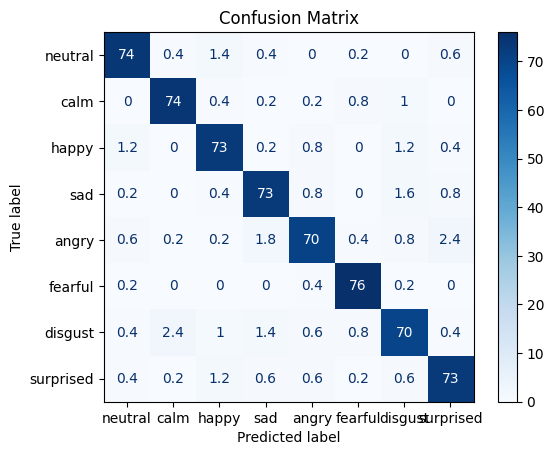


Classification Report:

              precision    recall  f1-score   support

     neutral       0.96      0.97      0.97        77
        calm       0.99      0.95      0.97        77
       happy       0.99      0.88      0.93        77
         sad       0.96      0.96      0.96        76
       angry       0.97      0.95      0.96        77
     fearful       0.96      1.00      0.98        76
     disgust       0.85      0.99      0.92        77
   surprised       0.97      0.94      0.95        77

    accuracy                           0.95       614
   macro avg       0.96      0.95      0.95       614
weighted avg       0.96      0.95      0.95       614



In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader


# ========================
# CONFIG
# ========================
FEATURE_PATH = "ser_fused_features_smote_3072.npy"
LABEL_PATH   = "ser_labels_smote_3072.npy"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
EPOCHS = 100
LR = 3e-4
KFOLDS = 5
PATIENCE = 15

SEQ_CHUNKS = 6
WARMUP_EP = 5
NOISE_STD = 0.02
MIXUP_ALPHA = 0.3


EMOTION_NAMES = [
    "neutral","calm","happy","sad",
    "angry","fearful","disgust","surprised"
]


# ========================
# LOAD DATA
# ========================
X = np.load(FEATURE_PATH).astype(np.float32)
y = np.load(LABEL_PATH).astype(np.int64)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

NUM_CLASSES = len(np.unique(y))

assert X.shape[1] % SEQ_CHUNKS == 0

SEQ_LEN  = SEQ_CHUNKS
STEP_DIM = X.shape[1] // SEQ_CHUNKS


# ========================
# AUGMENTATION
# ========================
def add_noise(x):
    return x + torch.randn_like(x) * NOISE_STD


def mixup(x, y_onehot, alpha=0.3):

    if alpha <= 0:
        return x, y_onehot

    lam = np.random.beta(alpha, alpha)

    idx = torch.randperm(x.size(0), device=x.device)

    x_mix = lam*x + (1-lam)*x[idx]
    y_mix = lam*y_onehot + (1-lam)*y_onehot[idx]

    return x_mix, y_mix


# ========================
# DATASET
# ========================
class SERDataset(Dataset):

    def __init__(self, X, y, augment=False):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment


    def __len__(self):

        return len(self.X)


    def __getitem__(self, idx):

        x = self.X[idx]

        if self.augment:
            x = add_noise(x)

        return x, self.y[idx]


# ========================
# MODEL
# ========================
class SERModel(nn.Module):

    def __init__(self, step_dim, seq_len, num_classes):

        super().__init__()

        d_model = 256

        self.input_proj = nn.Sequential(
            nn.Linear(step_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

        self.bilstm = nn.LSTM(
            d_model,
            d_model//2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=4,
            dropout=0.1,
            batch_first=True
        )

        self.ln = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model,256),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(256,128),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(128,num_classes)
        )


    def forward(self,x):

        B = x.size(0)

        x = x.view(B,SEQ_LEN,STEP_DIM)

        x = self.input_proj(x)

        x,_ = self.bilstm(x)

        attn_out,_ = self.attn(x,x,x)

        x = self.ln(x+attn_out)

        x = x.mean(dim=1)

        return self.classifier(x)


# ========================
# LABEL SMOOTHING LOSS
# ========================
class LabelSmoothingLoss(nn.Module):

    def __init__(self,num_classes,weight=None,smoothing=0.1):

        super().__init__()

        self.weight = weight
        self.smoothing = smoothing
        self.num_classes = num_classes


    def forward(self,logits,target):

        log_probs = torch.log_softmax(logits,dim=1)

        if target.dim()==1:

            one_hot = torch.zeros_like(log_probs).scatter_(1,target.unsqueeze(1),1)

        else:

            one_hot = target


        smooth_target = one_hot*(1-self.smoothing) + self.smoothing/self.num_classes

        loss = -(smooth_target*log_probs).sum(dim=1)


        if self.weight is not None:

            if target.dim()==2:
                hard = one_hot.argmax(dim=1)
            else:
                hard = target

            w = self.weight[hard]

            loss = (loss*w).sum()/w.sum()

        else:

            loss = loss.mean()

        return loss


# ========================
# LR SCHEDULER
# ========================
def scheduler_fn(opt):

    def lr_lambda(ep):

        if ep < WARMUP_EP:
            return (ep+1)/WARMUP_EP

        progress = (ep-WARMUP_EP)/(EPOCHS-WARMUP_EP)

        return 0.5*(1+np.cos(np.pi*progress))

    return optim.lr_scheduler.LambdaLR(opt,lr_lambda)


# ========================
# TRAINING LOOP
# ========================
kfold = StratifiedKFold(n_splits=KFOLDS,shuffle=True,random_state=42)

conf_matrix_sum = np.zeros((NUM_CLASSES,NUM_CLASSES))

fold_scores=[]


for fold,(train_idx,val_idx) in enumerate(kfold.split(X,y)):

    print("\n===== Fold",fold+1,"=====")

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X[train_idx])
    X_val   = scaler.transform(X[val_idx])

    y_train = y[train_idx]
    y_val   = y[val_idx]


    class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(y_train),
    y=y_train
      )

    class_weights = class_weights * 2.0

    class_weights = torch.tensor(class_weights,dtype=torch.float32).to(DEVICE)


    train_loader = DataLoader(
        SERDataset(X_train,y_train,augment=True),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        SERDataset(X_val,y_val),
        batch_size=BATCH_SIZE
    )


    model = SERModel(STEP_DIM,SEQ_LEN,NUM_CLASSES).to(DEVICE)

    criterion = LabelSmoothingLoss(
        NUM_CLASSES,
        weight=class_weights
    )

    optimizer = optim.AdamW(model.parameters(),lr=LR,weight_decay=5e-4)

    scheduler = scheduler_fn(optimizer)


    best_val=0
    patience_ctr=0


    for epoch in range(EPOCHS):

        model.train()

        for x_batch,y_batch in train_loader:

            x_batch=x_batch.to(DEVICE)
            y_batch=y_batch.to(DEVICE)

            one_hot=torch.zeros(
                x_batch.size(0),
                NUM_CLASSES,
                device=DEVICE
            ).scatter_(1,y_batch.unsqueeze(1),1)

            x_batch,soft_labels=mixup(x_batch,one_hot,MIXUP_ALPHA)

            optimizer.zero_grad()

            outputs=model(x_batch)

            loss=criterion(outputs,soft_labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

            optimizer.step()

        scheduler.step()


        model.eval()

        preds=[]
        targets=[]

        with torch.no_grad():

            for xb,yb in val_loader:

                xb=xb.to(DEVICE)

                out=model(xb)

                p=torch.argmax(out,1).cpu().numpy()

                preds.extend(p)
                targets.extend(yb.numpy())


        val_acc=(np.array(preds)==np.array(targets)).mean()

        print("Epoch",epoch+1,"Val Acc:",round(val_acc,4))


        if val_acc>best_val:

            best_val=val_acc

            best_preds=preds
            best_targets=targets

            patience_ctr=0

        else:

            patience_ctr+=1

            if patience_ctr>=PATIENCE:

                print("Early stopping")

                break


    fold_scores.append(best_val)

    conf_matrix_sum+=confusion_matrix(best_targets,best_preds)


# ========================
# RESULTS
# ========================
print("\nMean Accuracy:",np.mean(fold_scores))


cm=conf_matrix_sum/KFOLDS

disp=ConfusionMatrixDisplay(cm,display_labels=EMOTION_NAMES)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()


print("\nClassification Report:\n")

print(classification_report(best_targets,best_preds,target_names=EMOTION_NAMES))